In [1]:
import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

(a) Wybrać jeden schemat: jednokrokowy (Rungego-Kutty) albo liniowy schemat wielokrokowy (z zastrzeżeniem, że nie może to być schemat Eulera otwarty ani zamknięty).

W moim projekcie oprogramuję otwarty schemat Rungego-Kutny o poziomie 4. Macierze reguły są dane wzorami: $c$ ma postać:

$$ 
c=\begin{bmatrix}
0 \\[5pt]
\frac{1}{3} \\[5pt]
\frac {2}{3} \\[5pt]
1
\end{bmatrix},\quad
A=\begin{bmatrix}
0 & 0 & 0 & 0 \\[5pt]
\frac{1}{3} & 0 & 0 & 0 \\[5pt]
-\frac{1}{3} & 1 & 0 & 0 \\[5pt]
1 & -1 & 1 & 0 \\
\end{bmatrix},\quad
b=\begin{bmatrix}
\frac{1}{8} \\[5pt]
\frac{3}{8} \\[5pt]
\frac{3}{8} \\[5pt]
\frac{1}{8} \\
\end{bmatrix}. 
$$

(b) Wyznaczyć teoretyczny rząd wybranego schematu (bezpośrednio lub w oparciu o odpowiednie własności, twierdzenia, wykład czy literaturę).

Ponieważ schemat ten jest otwarty, to na podstawie twierdzenia 11. z wykładu 8:

"Niech schemat Rungego-Kutty spełnia warunek
$$ Ae = c. $$
Schemat Rungego-Kutty ma rząd 4 wtedy i tylko wtedy, gdy spełnione są wszystkie warunki:
$$
\begin{align*}
&b^T e=1 \\
&b^T c = \frac{1}{2} \\
&b^T c^2 = \frac{1}{3} \\
&b^T Ac = \frac{1}{6} \\
&b^T c^3 = \frac{1}{4} \\
&b^T diag(c)Ac = \frac{1}{8} \\
&bAc^2 = \frac{1}{12} \\
&b^T A^2 c = \frac{1}{24}"
\end{align*}
$$
 stwierdzamy, że omawiany schemat jest dokładnie rzędu 4. Sprawdzenie warunków tabeli znajduje się poniżej:

In [2]:
b = np.array([1/8, 3/8, 3/8, 1/8])
c = np.array([0, 1/3, 2/3, 1])
A = np.array([[0,0,0,0],[1/3,0,0,0],[-1/3,1,0,0],[1,-1,1,0]])
e = (np.array([1,1,1,1]))
c2 = np.array([0, 1/9, 4/9, 1])
c3 = np.array([0, 1/27, 8/27, 1])
c_diag = np.diag(c)
A2 = np.dot(A, A)

print(np.dot(b, e) == 1)
print(np.dot(b, c) == 1/2)
print(np.dot(b, c2) == 1/3)
print(np.dot(b, np.dot(A, c)) == 1/6)
print(np.dot(b, c3) == 1/4)
print(np.dot(b, np.dot(c_diag, np.dot(A, c))) == 1/8)
print(np.dot(b, np.dot(A, c2)) == 1/12)
print(np.dot(b, np.dot(A2, c)) == 1/24)

True
True
True
True
True
True
True
True


(c) Wyznaczyć obszar absolutnej stabilności wybranego schematu (zilustrować rysunkiem, wskazać odpowiedni warunek, podać postać funkcji stabilności, uzasadnić A-stabilność o ile dotyczy).

Teraz zajmę się wyznaczeniem obszaru stabilności. Zacznę od wyznaczenia funkcji stabilności, korzystając z twierdzenia 15. z wykładu 7.

In [3]:
z = sp.Symbol('z')

A = sp.Matrix(A)
b = sp.Matrix(b)
e = sp.Matrix(e)

I = sp.eye(4)

R_sp = sp.simplify((I - z*A + z*e*b.T).det() / (I - z*A).det()) # funkcja symboliczna z sympy
R = sp.lambdify(z, R_sp, 'numpy') # przekształcam na funkcję numeryczną

Funkcja stabilności ma postać:

In [4]:
print(R_sp)

0.0416666666666667*z**4 + 0.166666666666667*z**3 + 0.5*z**2 + 1.0*z + 1.0


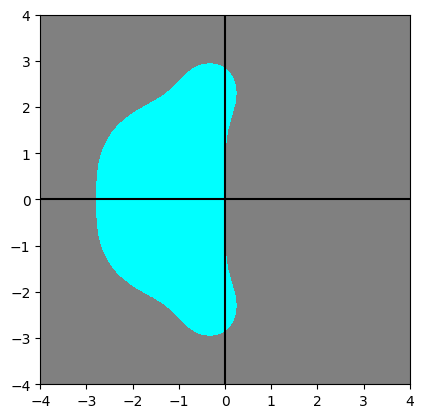

In [5]:
x = np.linspace(-4, 4, 1000)
y = np.linspace(-4, 4, 1000)
X, Y = np.meshgrid(x, y) # siatka punktów
Z = X + 1j*Y
mask = np.abs(R(Z))<1

fig, ax = plt.subplots()
ax.contourf(X, Y, mask, levels = 1, colors = ['grey', 'cyan'])
ax.set_aspect('equal') # ustawiam równe proporcje na obu osiach
ax.axhline(color = 'black') # koloruję osie na czarno
ax.axvline(color = 'black') #
plt.show()

Ponieważ, zgodnie z definicją: "Metodę nazywamy A-stabilną, gdy obszar absolutnej stabilności metody zawiera lewą półpłaszczyznę zespoloną," to na podstawie rysunku wnioskujemy, że omawiana metoda nie jest A-stabilna. Co więcej, Uwaga 9 w wykładzie 7. mówi nam, że schemat otwarty nie może być A-stabilny. 

(d) Wybrać problem początkowy. Może to być równanie nieliniowe, układ równań. Nie może to być równanie liniowe (rozumiane w sensie równań różniczkowych zwyczajnych), czyli niedopuszczalne jest w szczególności równanie testowe oraz problem Prothero-Robinsona.

Na tapet wezmę równanie logistyczne postaci: 
$$
\begin{cases}
x'(t) = x(t)\big(1 - x(t)\big), \quad t \in [0,1] \\
x(0) = \frac{1}{2}
\end{cases}.
$$

Rozwiązaniem tego problemu jest funkcja
$$
x(t)=\frac{1}{1+e^{-t}}.
$$

(e) Zastosować wybrany wcześniej schemat do wybranego problemu, wyniki porównać z rozwiązaniem dokładnym (jeżeli jest znane) lub z rozwiązaniem referencyjnym (można je uzyskać za pomocą NDSolve w Mathematice, w Pythonie pewnie też coś się znajdzie, w R jest pakiet deSolve) np. na wykresie.

Najpierw wyznaczę parametry $K_1,\dots,K_4$ za pomocą biblioteki sympy. 

In [6]:
xk = sp.symbols('xk')
h = sp.symbols('h')

K1 = xk-xk**2
# print(f'K1: {K1}\n')

K2 = sp.simplify((xk + (h/3)*K1)-(xk + (h/3)*K1)**2)
# print(f'K2: {K2}\n')

K3 = sp.simplify(xk - (h/3)*K1 + h*K2 - (xk - (h/3)*K1 + h*K2)**2)
# print(f'K3: {K3}\n')

K4 = sp.simplify(xk + h*K1 - h*K2 + h*K3 - (xk + h*K1 - h*K2 + h*K3)**2)
# print(f'K4: {K4}\n')

# K4.subs({xk: 0.5, h: 0.1}) - w ten sposób się odwołuję do wartości, gdyby mi to było potrzebne

K1 = lambda xk, h: -xk**2 + xk
K2 = lambda xk, h: xk*(-3*h*(xk - 1) - xk*(h*(xk - 1) - 3)**2 + 9)/9
K3 = lambda xk, h: xk*(27*h*(xk - 1) - 9*h*(3*h*(xk - 1) + xk*(h*(xk - 1) - 3)**2 - 9) - xk*(3*h*(xk - 1) - h*(3*h*(xk - 1) + xk*(h*(xk - 1) - 3)**2 - 9) + 9)**2 + 81)/81
K4 = lambda xk, h: xk*(-6561*h*(xk - 1) + 729*h*(3*h*(xk - 1) + xk*(h*(xk - 1) - 3)**2 - 9) + 81*h*(27*h*(xk - 1) - 9*h*(3*h*(xk - 1) + xk*(h*(xk - 1) - 3)**2 - 9) - xk*(3*h*(xk - 1) - h*(3*h*(xk - 1) + xk*(h*(xk - 1) - 3)**2 - 9) + 9)**2 + 81) - xk*(-81*h*(xk - 1) + 9*h*(3*h*(xk - 1) + xk*(h*(xk - 1) - 3)**2 - 9) + h*(27*h*(xk - 1) - 9*h*(3*h*(xk - 1) + xk*(h*(xk - 1) - 3)**2 - 9) - xk*(3*h*(xk - 1) - h*(3*h*(xk - 1) + xk*(h*(xk - 1) - 3)**2 - 9) + 9)**2 + 81) + 81)**2 + 6561)/6561


Skoro mam wyznaczone parametry $K_1,\dots,K_4,$ to mogę przejść do wyznaczenia siatki punktów i wartości w węzłach. 

In [7]:
f = lambda t: 1/(1 + np.exp(-t)) # rozwiązanie dokładne


def rk(n):
    x=np.zeros(n)
    h=1/(n-1)
    x[0] = 1/2
    for k in range(n-1):
        x[k+1] = x[k] + h*((1/8)*K1(x[k], h) + (3/8)*K2(x[k], h) + (3/8)*K3(x[k], h) + (1/8)*K4(x[k], h))
    return x

def draw(x):
    t = np.linspace(0, 1, len(x))
    fig, ax = plt.subplots()
    ax.scatter(t, x, color = 'r', s = 13)
    ax.plot(t, f(t), color = 'b')
    plt.show()

Porównajmy na rysunku wykres rezultatu omawianej metody (czerwony) z wykresem rozwiązania dokładnego (niebieski), weźmiemy liczebność siatki 100. 

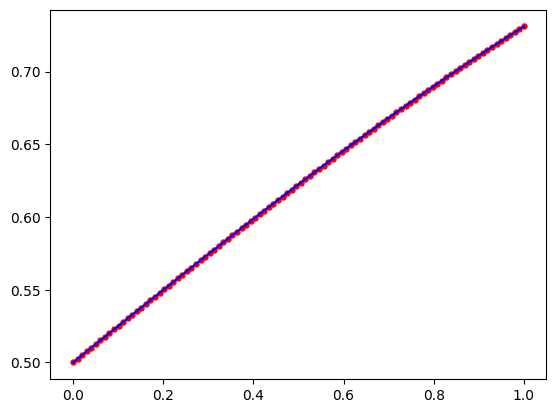

In [8]:
draw(rk(100))

(f) Używając tego samego równania wyznaczyć numeryczny rząd wybranych schematów metodą połowienia kroku. Wyniki przedstawić w formie tabeli i wykresu „loglog plot” z odpowiednią prostą odpowiadającą rzędowi teoretycznemu.

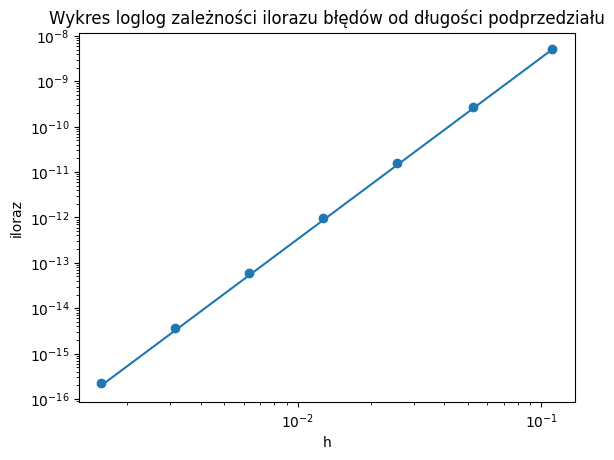

,n,h,err_n/err_2n,log_16
0,10,0.1111111111111111,18.25027175052882,1.0474615102709823
1,20,0.05263157894736842,17.16211769061478,1.0252889194085628
2,40,0.02564102564102564,16.58408186469585,1.0129318095251705
3,80,0.012658227848101266,16.317254174397032,1.0070815999017044
4,160,0.006289308176100629,16.333333333333332,1.007436835848513
5,320,0.003134796238244514,16.5,1.0110985298396133
6,640,0.001564945226917058,-,-


In [9]:
def err(x):
    return np.abs(x[len(x)-1] - f(1))

ns = [5*2**i for i in range(1, 8)] # przy gęstszej siatce iloraz zaczyna być niedeterministyczny z powodu błędów na poziomie reprezentacji
hs = [1/(k-1) for k in ns]

errs = []
for n in ns:
    errs.append(err(rk(n)))

iloraz_bledow = []
for i in range(len(errs)-1):
    iloraz_bledow.append(errs[i]/errs[i+1])

ps = [np.log(p)/np.log(16) for p in iloraz_bledow]

plt.scatter(hs, errs)
plt.plot(hs, [errs[0]/(hs[0]**4) * (h**4) for h in hs])
plt.xscale('log')
plt.yscale('log')
plt.xlabel('h')
plt.ylabel('iloraz')
plt.title('Wykres loglog zależności ilorazu błędów od długości podprzedziału')
plt.show()

iloraz_bledow.append('-')
ps.append('-')
tabela = np.vstack([ns, hs, iloraz_bledow, ps])
tabela = pd.DataFrame(tabela.T)
tabela.columns = ['n', 'h', 'err_n/err_2n', 'log_16']
tabela

(g) Wybrać układ dwóch (lub więcej) równań liniowych jednorodnych, którego macierz ma wartości własne o częściach rzeczywistych ujemnych (np. dwie rzeczywiste, ujemne wartości własne spełniają ten warunek). Przeprowadzić obliczenia za pomocą wybranego schematu z krokiem należącym, granicznym oraz nienależącym do obszaru absolutnej stabilności danego schematu (jak w 3-cim zadaniu numerycznym). Zilustrować na wykresie stabilność lub jej brak w tych trzech przypadkach. Uwaga: warunek początkowy dla tego układu nie może być trywialny (tzn. różny od punktu (0,0)). W przypadku wybrania schematu A-stabilnego obliczenia te wykonać schematem otwartym np. Heuna

Przywołajmy wzory definiujące metody Rungego-Kutny:
$$
x_{k+1} = x_k + h\sum_{i=1}^{s}{b_i K_i},\quad K_i = f\bigg( t_k + c_i h,\space x_k + h\sum_{j=1}^{s}{a_{ij} K_j}\bigg),\quad i = 1, 2,\dots , s.
$$

Rozważmy układ równań liniowych o stałych współczynnikach o macierzy F:
$$
F = \begin{bmatrix}
-0.1 & -1 \\
1 & -0.1
\end{bmatrix},
$$
z warunkiem początkowym
$$
x_0 = \begin{bmatrix}
2 \\ 1
\end{bmatrix}.
$$
Rozwiązaniem tego układu jest:
$$
\begin{bmatrix}
e^{-0.1t}(2\cos t - \sin t) \\ e^{-0.1t}(2\sin t + \cos t)
\end{bmatrix}.
$$
Wartości własne to $-0.1\pm i.$

Metodą bisekcji szukam kroku granicznego. Skorzystam z wcześniej podanego wzoru na funkcję stabilności. 

In [10]:
λ = -0.1 + 1j # stała λ

# funkcja metody bisekcji
def bisect(f, arg1, arg2, e):
    while np.abs(arg1 - arg2) > e:
        if f(arg1) * f((arg1 + arg2)/2) < 0:
            arg2 = (arg1 + arg2)/2
        else:
            arg1 = (arg1 + arg2)/2
    return (arg1 + arg2)/2

R = lambda h: np.abs(0.0416666666666667*(λ*h)**4 + 0.166666666666667*(λ*h)**3 + 0.5*(h*λ)**2 + 1.0*(h*λ) + 1.0) - 1

h_gran = bisect(R, 1/2000, 2000, 10**(-12))
print(f'Krok graniczny wynosi {h_gran}.')

Krok graniczny wynosi 2.935970302841789.


In [11]:
F = np.array([[-0.1, -1], [1, -0.1]])

x0 = np.array([2, 1])
f = lambda x: F @ x

A = np.array(A)
b = np.array(b)
c = np.array(c)

K1 = lambda xk: f(xk)
K2 = lambda xk, h: f(xk + (h/3)*K1(xk))
K3 = lambda xk, h: f(xk - (h/3)*K1(xk) + h*K2(xk, h))
K4 = lambda xk, h: f(xk + h*K1(xk) - h*K2(xk, h) + h*K3(xk, h))

nast = lambda xk, h: xk + h*(b[0]*K1(xk) + b[1]*K2(xk, h) + b[2]*K3(xk, h) + b[3]*K4(xk, h)) # funkcja zwracająca x_{k+1}

def rozwiazanie(h, i): # funkcja zwracająca listę wektorów przybliżeń
    xk = x0 
    rozw1 = [x0[0]] # lista wartości aproksymacji na pierwszej współrzędnej
    rozw2 = [x0[1]] # lista wartości aproksymacji na pierwszej współrzędnej
    for k in range(i-1):
        xk1 = nast(xk, h) # wyliczam następny wektor aproksymacji
        rozw1.append(xk1[0])
        rozw2.append(xk1[1])
        xk = xk1 # przygotowanie do następnego kroku
    return rozw1, rozw2

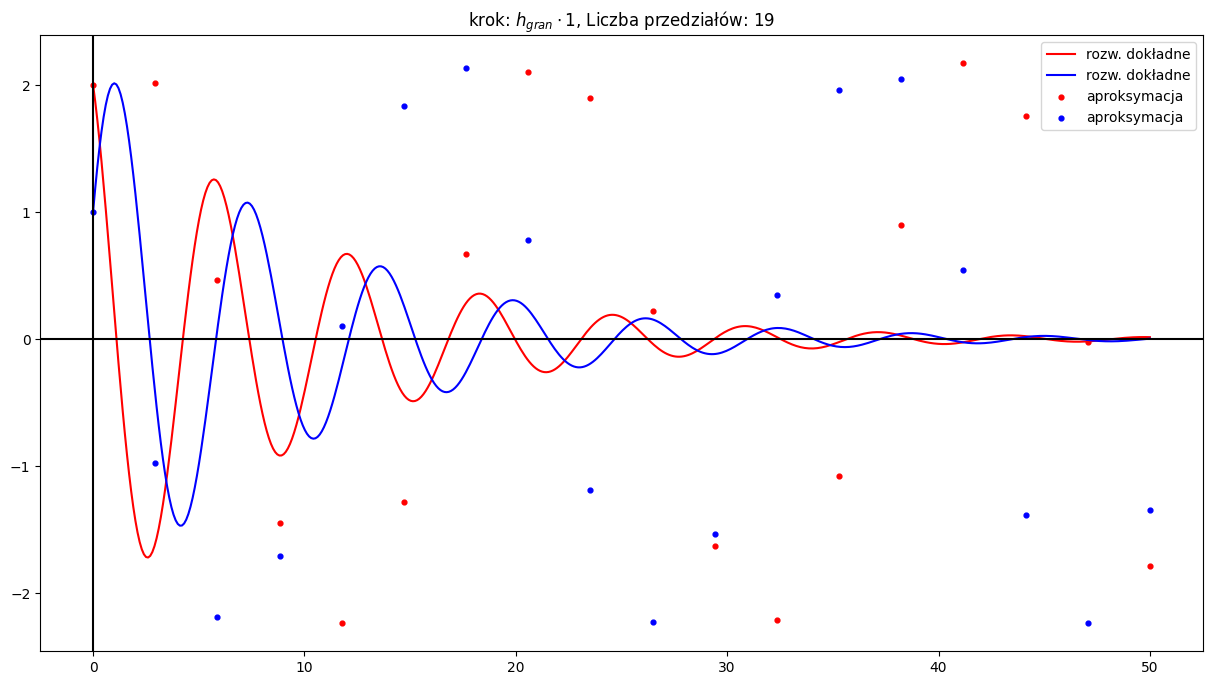

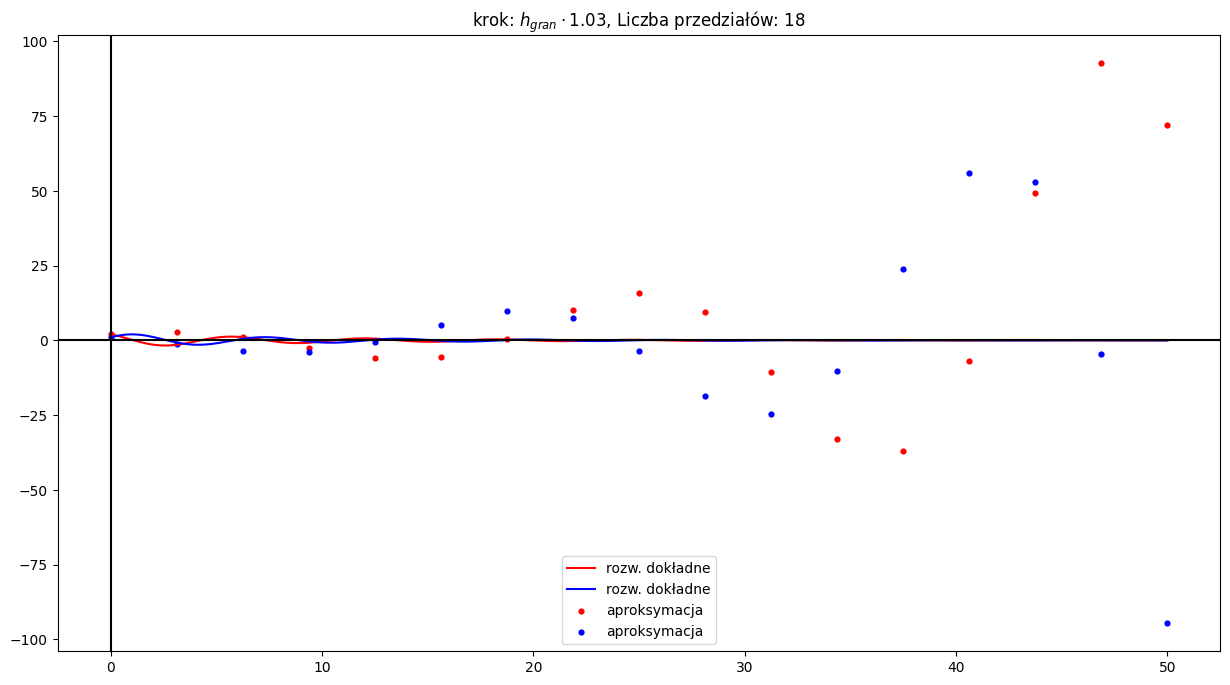

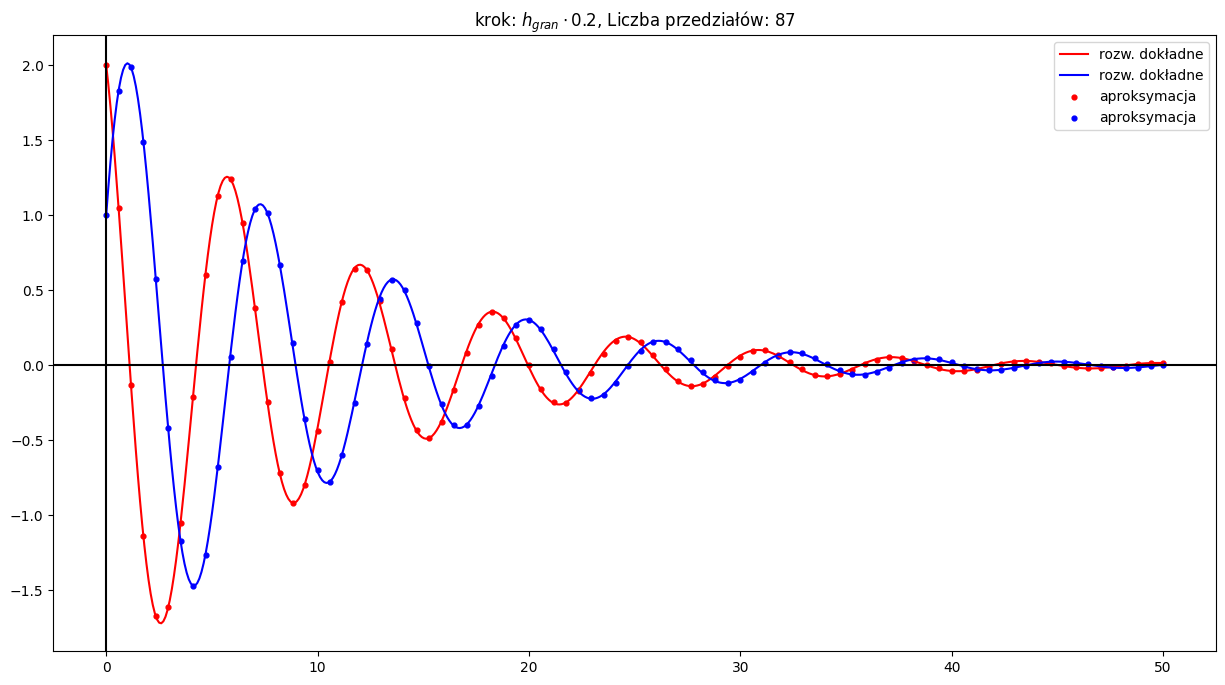

In [12]:
sol1 = lambda t: np.exp(-0.1*t)*(2*np.cos(t) - np.sin(t)) # rozwiązanie dokładne pierwszej współrzędnej
sol2 = lambda t: np.exp(-0.1*t)*(2*np.sin(t) + np.cos(t)) # rozwiązanie dokładne drugiej współrzędnej
hs = [1, 1.03, 0.2]
for a in hs:
    N = int(50/(a*h_gran)) + 1 # Liczba kroków potrzebna, by przy danej długości kroku ostatni punkt podziału był w punkcie 5 
    time = np.linspace(0, 50, N) 
    time_s = np.linspace(0, 50, 500) # siatka do rysowania rozwiązań dokładnych
    fig, ax = plt.subplots(figsize = (15, 8))
    ax.plot(time_s, sol1(time_s), color = 'r', label = 'rozw. dokładne')
    ax.plot(time_s, sol2(time_s), color = 'b', label = 'rozw. dokładne')
    ax.scatter(time, rozwiazanie(a*h_gran, N)[0], color = 'r', label = 'aproksymacja', s = 12)
    ax.scatter(time, rozwiazanie(a*h_gran, N)[1], color = 'b', label = 'aproksymacja', s = 12)
    ax.set_title(rf"krok: $h_{{gran}} \cdot {a}$, Liczba przedziałów: {N+1}")
    ax.axvline(color = 'black')
    ax.axhline(color = 'black')
    ax.legend()
    plt.show()